# Обзор датасета резервной одометрии

Этот notebook строит **быструю инвентаризацию всех ROS 2 bag по `metadata.yaml`**. Он не декодирует 8,8 млн сообщений и поэтому подходит для первого знакомства, выбора прогонов и подготовки train/validation/test.

Что здесь можно увидеть:

- длительность, объём и количество сообщений каждого прогона;
- наличие эталонных GNSS-потоков;
- различия между трамваями `30618` и `30639`;
- кандидатов в повторяющиеся записи, которые нельзя случайно разнести между train и test.

> GNSS разрешён только как ground truth для офлайн-аналитики, метрик и начальной выставки. В основном контуре резервной одометрии используются только ручка контроллера и скорости тележек.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bag_analysis import (
    DATA_ROOT,
    candidate_duplicate_groups,
    scan_dataset,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print(f"Каталог данных: {DATA_ROOT}")

Каталог данных: C:\Users\vladm\Documents\Git\odometry-service\dataset\data


## 1. Инвентаризация

In [2]:
inventory = scan_dataset()

summary = pd.Series({
    "bag_count": len(inventory),
    "vehicles": inventory["vehicle_id"].nunique(),
    "total_duration_hours": inventory["duration_s"].sum() / 3600,
    "total_messages": inventory["message_count"].sum(),
    "total_size_mib": inventory["size_mib"].sum(),
    "median_duration_s": inventory["duration_s"].median(),
    "bags_with_any_gnss": inventory["has_any_gnss"].sum(),
    "bags_with_both_gnss": inventory["has_both_gnss"].sum(),
    "bags_without_gnss": (~inventory["has_any_gnss"]).sum(),
})

display(summary.to_frame("value"))
display(inventory.head())

,value
bag_count,122.000
vehicles,2.000
total_duration_hours,36.746
total_messages,"8,788,325.000"
total_size_mib,823.742
median_duration_s,"1,190.769"
bags_with_any_gnss,87.000
bags_with_both_gnss,86.000
bags_without_gnss,35.000


,bag_id,vehicle_id,duration_s,start_ns,message_count,size_mib,control_count,front_wheel_count,rear_wheel_count,master_fix_count,master_velocity_count,rover_fix_count,rover_velocity_count,has_master_gnss,has_rover_gnss,has_any_gnss,has_both_gnss
0,30618_e3d94878,30618,"1,168.392",1785128151198481682,91620,9.156,23421,11064,11072,11710,11438,11473,11442,True,True,True,True
1,30618_b83d854d,30618,"1,202.930",1785129339175454118,94540,9.434,24110,11461,11470,12054,11823,11856,11766,True,True,True,True
2,30618_b8044aa0,30618,"1,272.141",1785131978903320680,98927,9.906,25490,11660,11670,12745,12124,12679,12559,True,True,True,True
3,30618_76e1f9c7,30618,"1,295.530",1785133276364789687,100928,10.109,25959,11916,11926,12979,12469,12971,12708,True,True,True,True
4,30618_2f104a1d,30618,"1,248.441",1785135325646068375,97059,9.715,25018,11422,11432,12509,12254,12266,12158,True,True,True,True


### Проверки целостности

Эти проверки не доказывают корректность самих измерений, но быстро показывают неполную распаковку или неожиданное изменение структуры датасета.

In [3]:
integrity_checks = pd.Series({
    "metadata_read_for_every_bag": len(inventory) == len(list(DATA_ROOT.glob("*/metadata.yaml"))),
    "all_have_control": inventory["control_count"].gt(0).all(),
    "all_have_front_wheel": inventory["front_wheel_count"].gt(0).all(),
    "all_have_rear_wheel": inventory["rear_wheel_count"].gt(0).all(),
    "message_counts_positive": inventory["message_count"].gt(0).all(),
    "durations_positive": inventory["duration_s"].gt(0).all(),
})

integrity_checks.to_frame("passed")

,passed
metadata_read_for_every_bag,True
all_have_control,True
all_have_front_wheel,True
all_have_rear_wheel,True
message_counts_positive,True
durations_positive,True


## 2. Распределения прогонов

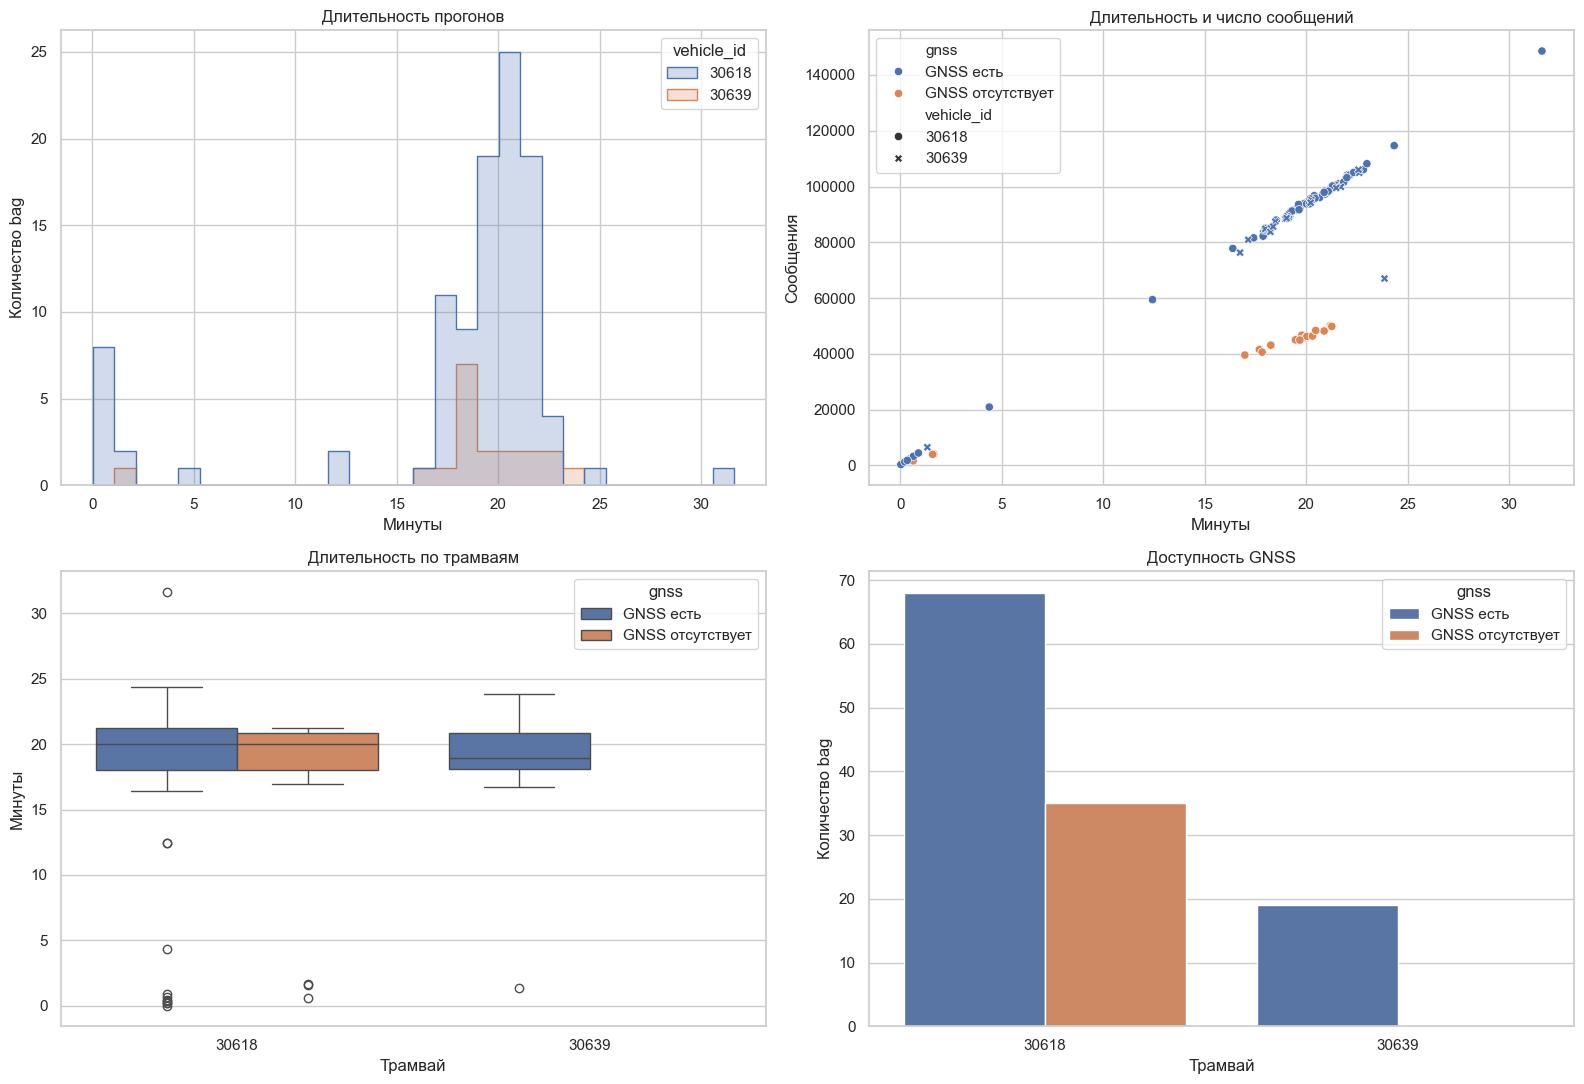

In [4]:
plot_data = inventory.assign(
    duration_min=inventory["duration_s"] / 60,
    gnss=inventory["has_any_gnss"].map({True: "GNSS есть", False: "GNSS отсутствует"}),
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(plot_data, x="duration_min", bins=30, hue="vehicle_id", element="step", ax=axes[0, 0])
axes[0, 0].set(title="Длительность прогонов", xlabel="Минуты", ylabel="Количество bag")

sns.scatterplot(
    plot_data,
    x="duration_min",
    y="message_count",
    hue="gnss",
    style="vehicle_id",
    ax=axes[0, 1],
)
axes[0, 1].set(title="Длительность и число сообщений", xlabel="Минуты", ylabel="Сообщения")

sns.boxplot(plot_data, x="vehicle_id", y="duration_min", hue="gnss", ax=axes[1, 0])
axes[1, 0].set(title="Длительность по трамваям", xlabel="Трамвай", ylabel="Минуты")

availability = (
    plot_data.groupby(["vehicle_id", "gnss"], observed=True)
    .size()
    .rename("bags")
    .reset_index()
)
sns.barplot(availability, x="vehicle_id", y="bags", hue="gnss", ax=axes[1, 1])
axes[1, 1].set(title="Доступность GNSS", xlabel="Трамвай", ylabel="Количество bag")

fig.tight_layout()
plt.show()

## 3. Покрытие каналов

In [5]:
coverage_by_vehicle = inventory.groupby("vehicle_id").agg(
    bags=("bag_id", "size"),
    duration_hours=("duration_s", lambda values: values.sum() / 3600),
    messages=("message_count", "sum"),
    control=("control_count", "sum"),
    front_wheel=("front_wheel_count", "sum"),
    rear_wheel=("rear_wheel_count", "sum"),
    master_fix=("master_fix_count", "sum"),
    master_velocity=("master_velocity_count", "sum"),
    rover_fix=("rover_fix_count", "sum"),
    rover_velocity=("rover_velocity_count", "sum"),
    bags_with_both_gnss=("has_both_gnss", "sum"),
    bags_without_gnss=("has_any_gnss", lambda values: (~values).sum()),
)

coverage_by_vehicle

,bags,duration_hours,messages,control,front_wheel,rear_wheel,master_fix,master_velocity,rover_fix,rover_velocity,bags_with_both_gnss,bags_without_gnss
vehicle_id,,,,,,,,,,,,
30618,103,30.840,7180506,2226641,1039916,1040426,728759,714973,717676,712115,68,35
30639,19,5.906,1607819,425750,199304,196982,198388,180777,203596,203022,18,0


## 4. Кандидаты в повторяющиеся записи

Совпадающие длительность и счётчики топиков — только **признак возможного дубликата**, а не доказательство. Перед разбиением выборки такие группы нужно подтвердить хешами `.db3` или сравнением временных диапазонов. Все bag одной подтверждённой группы должны попасть в одну часть выборки.

In [6]:
duplicate_candidates = candidate_duplicate_groups(inventory)

print(f"Кандидатов: {len(duplicate_candidates)} bag")
print(f"Групп кандидатов: {duplicate_candidates['candidate_group'].nunique() if not duplicate_candidates.empty else 0}")

duplicate_candidates[[
    "candidate_group",
    "bag_id",
    "vehicle_id",
    "duration_s",
    "message_count",
    "has_any_gnss",
]].head(50)

Кандидатов: 50 bag
Групп кандидатов: 25


,candidate_group,bag_id,vehicle_id,duration_s,message_count,has_any_gnss
83,0,30618_2cb9ce37,30618,745.776,59442,True
84,0,30618_5eb8d2c9,30618,745.776,59442,True
50,1,30618_3e012faf,30618,"1,018.789",39573,False
51,1,30618_bcc9e7a2,30618,"1,018.789",39573,False
29,2,30618_79b204dc,30618,"1,061.595",41525,False
30,2,30618_887a2b9a,30618,"1,061.595",41525,False
31,3,30618_2161b58b,30618,"1,069.820",40603,False
32,3,30618_f28179bb,30618,"1,069.820",40603,False
66,4,30618_4d487b0d,30618,"1,072.823",82202,True
67,4,30618_b3042f78,30618,"1,072.823",82202,True


## 5. Выбор прогонов для экспериментов

In [7]:
inventory_with_class = inventory.assign(
    recommended_use=np.select(
        [
            inventory["duration_s"].lt(120) & inventory["has_any_gnss"],
            inventory["duration_s"].ge(120) & inventory["has_both_gnss"],
            ~inventory["has_any_gnss"],
        ],
        [
            "быстрая отладка с truth",
            "оценка точности и калибровка",
            "устойчивость без доступных метрик truth",
        ],
        default="ручная проверка",
    )
)

selection = (
    inventory_with_class.sort_values(["recommended_use", "duration_s"])
    [[
        "bag_id",
        "vehicle_id",
        "duration_s",
        "message_count",
        "has_master_gnss",
        "has_rover_gnss",
        "recommended_use",
    ]]
)

selection.groupby("recommended_use", group_keys=False).head(10)

,bag_id,vehicle_id,duration_s,message_count,has_master_gnss,has_rover_gnss,recommended_use
22,30618_1551d0a9,30618,1.282,294,True,True,быстрая отладка с truth
17,30618_0d865417,30618,11.841,1075,True,True,быстрая отладка с truth
77,30618_45ff6f99,30618,13.097,1281,True,True,быстрая отладка с truth
97,30618_082f1d65,30618,20.532,1793,True,True,быстрая отладка с truth
16,30618_bc5e53c2,30618,26.309,2222,True,True,быстрая отладка с truth
76,30618_98161270,30618,38.654,3266,True,True,быстрая отладка с truth
78,30618_bab2fe58,30618,53.552,4450,True,True,быстрая отладка с truth
117,30639_0ab96c59,30639,79.788,6508,True,True,быстрая отладка с truth
85,30618_af7496f0,30618,262.948,20921,True,True,оценка точности и калибровка
83,30618_2cb9ce37,30618,745.776,59442,True,True,оценка точности и калибровка


## Как продолжить

1. Выберите `bag_id` из таблиц выше.
2. Откройте `explore_bag.ipynb` и замените параметр `BAG_ID`.
3. Для train/validation/test делите данные **целыми bag**, учитывайте трамвай и подтверждённые дубликаты.
4. Bag без GNSS полезны для проверки доступности и устойчивости, но не дают измерить фактическую ошибку положения или скорости.
5. Не интерпретируйте `recorded_ns - header_ns` как чистую сетевую задержку без отдельного анализа часов.